In [27]:
import os
import zipfile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from imblearn.over_sampling import RandomOverSampler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pickle
from plotly import express as px


In [28]:
# Thiết lập chung
ds_path = 'datasets/titanic/'
train_path = os.path.join(ds_path, 'train.csv')
test_path = os.path.join(ds_path, 'test.csv')

In [29]:
# Giải nén tập dữ liệu
with zipfile.ZipFile('datasets/titanic.zip', 'r') as f:
	f.extractall(ds_path)

In [30]:
# Nạp dữ liệu
train_ds = pd.read_csv(train_path, delimiter=',')
test_ds = pd.read_csv(test_path, delimiter=',')
train_ds.sample(50)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
238,239,0,2,"Pengelly, Mr. Frederick William",male,19.0,0,0,28665,10.5000,NaN,S
37,38,0,3,"Cann, Mr. Ernest Charles",male,21.0,0,0,A./5. 2152,8.0500,NaN,S
569,570,1,3,"Jonsson, Mr. Carl",male,32.0,0,0,350417,7.8542,NaN,S
215,216,1,1,"Newell, Miss. Madeleine",female,31.0,1,0,35273,113.2750,D36,C
725,726,0,3,"Oreskovic, Mr. Luka",male,20.0,0,0,315094,8.6625,NaN,S
553,554,1,3,"Leeni, Mr. Fahim (""Philip Zenni"")",male,22.0,0,0,2620,7.2250,NaN,C
596,597,1,2,"Leitch, Miss. Jessie Wills",female,NaN,0,0,248727,33.0000,NaN,S
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
510,511,1,3,"Daly, Mr. Eugene Patrick",male,29.0,0,0,382651,7.7500,NaN,Q
293,294,0,3,"Haas, Miss. Aloisia",female,24.0,0,0,349236,8.8500,NaN,S


In [31]:
train_ds.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [32]:
# Loại bỏ thuộc tính dư thừa
train_ds.drop(columns=['Name', 'PassengerId', 'Ticket'], inplace=True)
train_ds.columns

Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Cabin',
       'Embarked'],
      dtype='object')

In [33]:

# Xử lý cột Cabin
train_ds['HasCabin'] = np.where(train_ds['Cabin'].isna(), 0, 1)  # Nếu Cabin != N/A thì hascabin = 0 else 1
train_ds.drop(columns=['Cabin'], inplace=True)  # Loại bỏ cột Cabin


In [34]:
# Kiểm tra giá trị N/A (Train)
train_ds = train_ds.bfill().ffill()
train_ds.isna().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
HasCabin    0
dtype: int64

In [35]:
## Xử lý cột Sex
sex = sorted(train_ds['Sex'].unique())
print('Sex labels:', sex)
train_ds['Sex'].replace(sex, range(len(sex)), inplace=True)
train_ds['Sex'].sample(10)

Sex labels: ['female', 'male']


602    1
399    0
251    0
159    1
222    1
700    0
507    1
667    1
15     0
890    1
Name: Sex, dtype: int64

In [36]:
## Xử lý cột Embarked
embarked = sorted(train_ds['Embarked'].unique())
print('Embarked label:', embarked)
train_ds['Embarked'].replace(embarked, range(len(embarked)), inplace=True)
train_ds['Embarked'].sample(10)

Embarked label: ['C', 'Q', 'S']


792    2
177    0
312    2
10     2
732    2
136    2
134    2
709    0
82     1
153    2
Name: Embarked, dtype: int64

In [37]:
## Kiểm tra kiểu dữ liệu
train_ds.dtypes

Survived      int64
Pclass        int64
Sex           int64
Age         float64
SibSp         int64
Parch         int64
Fare        float64
Embarked      int64
HasCabin      int32
dtype: object

Survived    0.478523
Pclass     -0.630548
Sex        -0.618921
Age         0.342346
SibSp       3.695352
Parch       2.749117
Fare        4.787317
Embarked   -1.257476
HasCabin    1.292367
dtype: float64


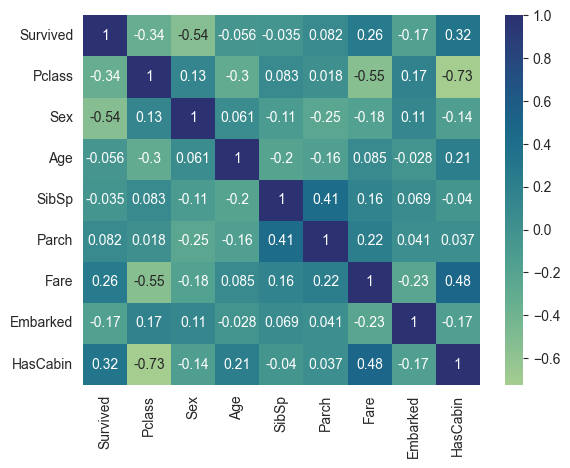

In [38]:
# Biểu đồ phân bố dữ liệu
print(train_ds.skew())

sns.heatmap(train_ds.corr(), cmap='crest', annot=True)
plt.show()

In [39]:
# Chuyển kiểu dữ liệu
train_ds['Age'] = train_ds['Age'].astype(int)  # Age -> Int
train_ds['Fare'] = train_ds['Fare'].astype(float)  # Fare -> Float

train_ds.dtypes

Survived      int64
Pclass        int64
Sex           int64
Age           int32
SibSp         int64
Parch         int64
Fare        float64
Embarked      int64
HasCabin      int32
dtype: object

In [40]:
# Chuẩn hóa giá trị
StandardScaler().fit_transform(train_ds)
train_ds.describe()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,HasCabin
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,0.647587,29.846240,0.523008,0.381594,32.204208,1.534231,0.228956
std,0.486592,0.836071,0.477990,14.616288,1.102743,0.806057,49.693429,0.793021,0.420397
min,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,0.000000,21.000000,0.000000,0.000000,7.910400,1.000000,0.000000
50%,0.000000,3.000000,1.000000,29.000000,0.000000,0.000000,14.454200,2.000000,0.000000
75%,1.000000,3.000000,1.000000,39.000000,1.000000,0.000000,31.000000,2.000000,0.000000
max,1.000000,3.000000,1.000000,80.000000,8.000000,6.000000,512.329200,2.000000,1.000000


In [41]:
# Trực quan hóa dữ liệu
px.bar(
	train_ds,
	x='Pclass',
	y='Survived',
	color='Pclass',
	title='Tỉ lệ sống sót dựa trên hạng vé Pclass'
).show()

In [42]:
px.pie(
	train_ds,
	names='Survived',
	values='Sex',
	color='Sex',
	title='Tỉ lệ sống sót dựa trên giới tính Sex',
).show()

In [43]:
px.pie(
	train_ds,
	names='Survived',
	values='HasCabin',
	color='HasCabin',
	title='Tỉ lệ sống sót dựa trên HasCabin',
).show()

In [44]:
px.bar(
	train_ds,
	x='Age',
	y='Survived',
	color='Age',
	title='Tỉ lệ sống sót theo độ tuổi'
).show()

In [45]:
# Nạp dữ liệu cho mảng để Train
x = train_ds.drop(columns=['Survived'])
y = train_ds['Survived']

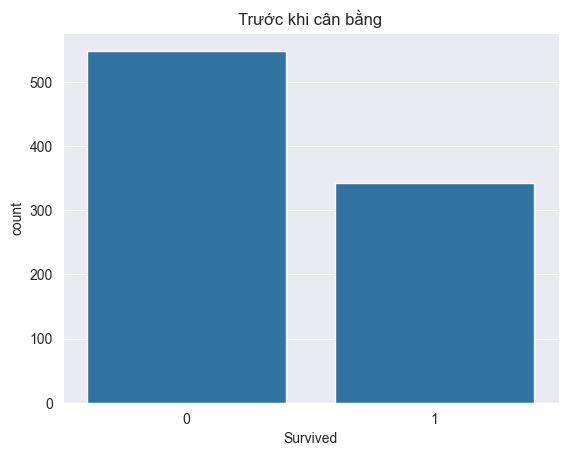

In [46]:
# Kiểm tra & tái cân bằng nhãn (nếu có)
plt.title('Trước khi cân bằng')
sns.countplot(train_ds, x='Survived')
plt.show()
# => Nhãn chưa cân bằng

In [47]:
# Tái cân bằng nhãn
a = RandomOverSampler(random_state=50)  # Tỉ lệ ngẫu nhiên là 50% (Set cố định để khi Train chọn thuạt toán tốt nhất)
x, y = a.fit_resample(x, y)

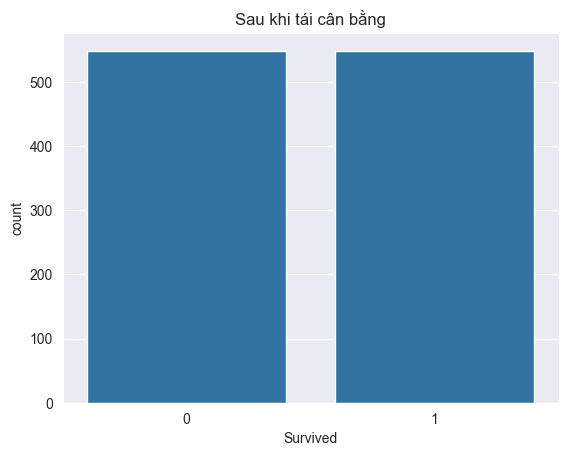

In [48]:
plt.title('Sau khi tái cân bằng')
sns.countplot(x=y)
plt.show()

In [49]:
# Tách tập dữ liệu
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=.2, stratify=y, random_state=50)

In [50]:
# Train mô hình bằng thuật toán Rừng ngẫu nhiên
model = RandomForestClassifier()
model.fit(x_train, y_train)

# Lưu mô hình
with open('models/titatic_model.pkl', 'wb') as f:
	pickle.dump(model, f)

== TRAIN ==
Score: 0.989749430523918
MSE: 0.010250569476082005
R2_Score: 0.958997722095672
== TEST ==
Score: 0.989749430523918
MSE: 0.10909090909090909
R2_Score: 0.5636363636363637


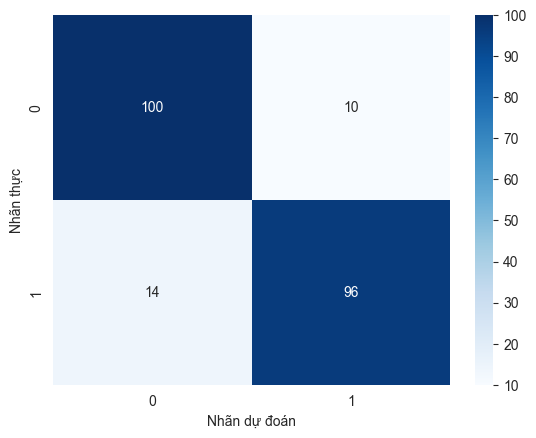

In [51]:
# Đánh giá mô hình
print('== TRAIN ==')
print('Score:', model.score(x_train, y_train))

# Tỉ lệ lỗi của mô hình
y_pred = model.predict(x_train)
mse = mean_squared_error(y_train, y_pred)
print('MSE:', mse)
r2 = r2_score(y_train, y_pred)
print('R2_Score:', r2)

print('== TEST ==')
print('Score:', model.score(x_train, y_train))
# Tỉ lệ lỗi của mô hình
y_pred = model.predict(x_test)
mse = mean_squared_error(y_test, y_pred)
print('MSE:', mse)
r2 = r2_score(y_test, y_pred)
print('R2_Score:', r2)

# Vẽ biểu đồ đánh giá Positive
y_pred = model.predict(x_test)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap='Blues')
plt.xlabel('Nhãn dự đoán')
plt.ylabel('Nhãn thực')
plt.show()

In [52]:
class_names = ['No Survived', 'Survived']
print(train_ds.columns)

# Bắt đầu dự đoán
def model_pred(data):
	data = np.reshape(data, (1, 8))
	print('=> Kết quả:', class_names[model.predict(data)[0]])

pred = [1, 0, 22, 0, 1, 14.5, 0]
pred_2 = [2, 1, 63, 1, 0, 26, 2]
pred_3 = [1, 0, 45, 1, 0, 52.5542, 2]
pred_4 = [1, 0, 23, 1, 0, 82.2667, 2, 1]

# model_pred(pred)
# model_pred(pred_2)
# model_pred(pred_3)
model_pred(pred_4)


Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
       'Embarked', 'HasCabin'],
      dtype='object')
=> Kết quả: Survived


D:\Python\data_science\venv\Lib\site-packages\sklearn\base.py:465: UserWarning:

X does not have valid feature names, but RandomForestClassifier was fitted with feature names

